In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import utulek

utulek.platform.import_globals_notebook(globals())

base_module = utulek
IS_NOTEBOOK_KERNEL_CODE = True
NOTEBOOK_NAME = 2026_07_27-t2i.2.ipynb
ASSET_PATH = /home/gilgamesh/main.syncthing/utulek/experiment/2026_07_27-t2i.ipynb.asset/
Loaded `/home/gilgamesh/main.syncthing/utulek/experiment/.env`.
torch: ['NVIDIA GeForce GTX 1080 Ti']
tf: /device:GPU:0
jax: [CudaDevice(id=0)]


In [4]:
from diffusers import ModularPipeline, AnimaModularPipeline, ComponentsManager, AnimaAutoBlocks

Modular Diffusers is currently an experimental feature under active development. The API is subject to breaking changes in future releases.


In [5]:
repo_id = "circlestone-labs/Anima-Base-v1.0-Diffusers"
device = "cuda"

model = AnimaModularPipeline.from_pretrained(repo_id)
model.load_components(torch_dtype=torch.bfloat16)
model.to("cpu")
torch.cuda.empty_cache()

/home/gilgamesh/main.syncthing/utulek/.venv/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Guiders are currently an experimental feature under active development. The API is subject to breaking changes in future releases.


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

In [6]:
blocks = model.blocks
blocks

AnimaAutoBlocks(
  Class: SequentialPipelineBlocks

  Description: Auto Modular pipeline for text-to-image generation using Anima.
      
      Supported workflows:
        - `text2image`: requires `prompt`


  Components:
      text_encoder (`Qwen3Model`)
      tokenizer (`Qwen2Tokenizer`)
      t5_tokenizer (`T5Tokenizer`)
      guider (`ClassifierFreeGuidance`)
      text_conditioner (`AnimaTextConditioner`)
      transformer (`CosmosTransformer3DModel`)
      scheduler (`FlowMatchEulerDiscreteScheduler`)
      vae (`AutoencoderKLQwenImage`)
      image_processor (`VaeImageProcessor`)

  Sub-Blocks:
    [0] text_encoder (AnimaTextEncoderStep)
       Description: Text encoder step that encodes Anima prompts into Qwen states and T5 token ids.

    [1] denoise (AnimaCoreDenoiseStep)
       Description: Denoise block that takes encoded Anima text inputs and runs the denoising process.

    [2] decode (AnimaDecodeStep)
       Description: Decode Anima latents into generated images.

)

In [7]:
b0 = blocks.sub_blocks["text_encoder"]
b0

AnimaTextEncoderStep {
  "_class_name": "AnimaTextEncoderStep",
  "_diffusers_version": "0.39.0"
}

In [8]:
b0p = b0.init_pipeline(repo_id)
b0p.load_components(torch_dtype=torch.bfloat16)

Guiders are currently an experimental feature under active development. The API is subject to breaking changes in future releases.


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

In [39]:
b0p.to(device)
b0po = b0p(prompt="""
masterpiece, best_quality, score_7, safe, @ichimi, 2girls, multiple girls, ononoki yotsugi, sengoku nadeko, monogatari (series), dress, highres, war, tank, military, smoke.

2 characters, Ononoki Yotsugi and Sengoku Nadeko from the Bakemonogatari anime standing, looking at the viewer, in front of a background of a battle, explosions, bombs. They wear blue and white dresses made from the Israeli flag, featuring a prominent Star of David. The Star of David is accurate and sharply portrayed.

Character 1 (left):
Ononoki is making a peace sign and looking at the viewer with an expressionless face, wearing an orange hat with eyes.

Character 2 (right);
Nadeko is crossing her arms looking at the viewer with an expression of pride and joy, wearing a newsboy cap.
""",
	negative_prompt=
	"worst quality, low quality, score_1, score_2, score_3, artist name, blurry, jpeg artifacts, chromatic aberration"
						)
b0po

PipelineState(
  values={
    prompt: '\nmasterpiece, best_quality, score_7, safe, @ichimi, 2girls, multiple girls, ononoki yotsugi, sengoku nadeko, monogatari (series), dress, highres, war, tank, military, smoke.\n\n2 characters, Ononoki Yotsugi and Sengoku Nadeko from the Bakemonogatari anime standing, looking at the viewer, in front of a background of a battle, explosions, bombs. They wear blue and white dresses made from the Israeli flag, featuring a prominent Star of David. The Star of David is accurate and sharply portrayed.\n\nCharacter 1 (left):\nOnonoki is making a peace sign and looking at the viewer with an expressionless face, wearing an orange hat with eyes.\n\nCharacter 2 (right);\nNadeko is crossing her arms looking at the viewer with an expression of pride and joy, wearing a newsboy cap.\n'
    negative_prompt: 'worst quality, low quality, score_1, score_2, score_3, artist name, blurry, jpeg artifacts, chromatic aberration'
    max_sequence_length: 512
    qwen_prompt_e

In [40]:
b0p.to("cpu")
torch.cuda.empty_cache()

In [11]:
b1 = blocks.sub_blocks["denoise"]
b1

AnimaCoreDenoiseStep(
  Class: SequentialPipelineBlocks

  Description: Denoise block that takes encoded Anima text inputs and runs the denoising process.


  Components:
      text_conditioner (`AnimaTextConditioner`)
      transformer (`CosmosTransformer3DModel`)
      scheduler (`FlowMatchEulerDiscreteScheduler`)
      guider (`ClassifierFreeGuidance`)

  Sub-Blocks:
    [0] text_conditioning (AnimaTextConditioningStep)
       Description: Map Qwen text encoder states and T5 token ids to Cosmos text conditioning for Anima.

    [1] input (AnimaTextInputStep)
       Description: Input processing step that expands Anima prompt embeddings for the requested image batch.

    [2] prepare_latents (AnimaPrepareLatentsStep)
       Description: Prepare noisy image latents and padding mask for Anima denoising.

    [3] set_timesteps (AnimaSetTimestepsStep)
       Description: Set the scheduler timesteps for Anima inference.

    [4] denoise (AnimaDenoiseStep)
       Description: Denoise step 

In [12]:
b1p = b1.init_pipeline(repo_id)
b1p.load_components(torch_dtype=torch.bfloat16)
b1p

/home/gilgamesh/main.syncthing/utulek/.venv/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Guiders are currently an experimental feature under active development. The API is subject to breaking changes in future releases.


AnimaModularPipeline {
  "_blocks_class_name": "AnimaCoreDenoiseStep",
  "_class_name": "AnimaModularPipeline",
  "_diffusers_version": "0.39.0",
  "scheduler": [
    "diffusers",
    "FlowMatchEulerDiscreteScheduler",
    {
      "pretrained_model_name_or_path": "circlestone-labs/Anima-Base-v1.0-Diffusers",
      "revision": null,
      "subfolder": "scheduler",
      "type_hint": [
        "diffusers",
        "FlowMatchEulerDiscreteScheduler"
      ],
      "variant": null
    }
  ],
  "text_conditioner": [
    "diffusers",
    "AnimaTextConditioner",
    {
      "pretrained_model_name_or_path": "circlestone-labs/Anima-Base-v1.0-Diffusers",
      "revision": null,
      "subfolder": "text_conditioner",
      "type_hint": [
        "diffusers",
        "AnimaTextConditioner"
      ],
      "variant": null
    }
  ],
  "transformer": [
    "diffusers",
    "CosmosTransformer3DModel",
    {
      "pretrained_model_name_or_path": "circlestone-labs/Anima-Base-v1.0-Diffusers",
      "revi

In [41]:
type(b1p).default_height = property(lambda self: 512)
type(b1p).default_width = property(lambda self: 512)
type(b1p).vae_scale_factor = property(lambda self: 8)
b1p.to(device)
b1po = b1p(**b0po.values, num_inference_steps=50)
b1po

  0%|          | 0/50 [00:00<?, ?it/s]

PipelineState(
  values={
    qwen_prompt_embeds: Tensor(dtype=torch.bfloat16, shape=torch.Size([1, 194, 1024]))
    qwen_attention_mask: Tensor(dtype=torch.int64, shape=torch.Size([1, 194]))
    t5_input_ids: Tensor(dtype=torch.int64, shape=torch.Size([1, 213]))
    t5_attention_mask: Tensor(dtype=torch.int64, shape=torch.Size([1, 213]))
    negative_qwen_prompt_embeds: Tensor(dtype=torch.bfloat16, shape=torch.Size([1, 31, 1024]))
    negative_qwen_attention_mask: Tensor(dtype=torch.int64, shape=torch.Size([1, 31]))
    negative_t5_input_ids: Tensor(dtype=torch.int64, shape=torch.Size([1, 36]))
    negative_t5_attention_mask: Tensor(dtype=torch.int64, shape=torch.Size([1, 36]))
    num_images_per_prompt: 1
    height: 512
    width: 512
    latents: Tensor(dtype=torch.bfloat16, shape=torch.Size([1, 16, 1, 64, 64]))
    generator: None
    num_inference_steps: 50
    sigmas: None
    prompt_embeds: Tensor(dtype=torch.bfloat16, shape=torch.Size([1, 512, 1024]))
    negative_prompt_embed

In [42]:
b1p.to("cpu")
torch.cuda.empty_cache()

In [34]:
b2 = blocks.sub_blocks["decode"]
b2

AnimaDecodeStep(
  Class: SequentialPipelineBlocks

  Description: Decode Anima latents into generated images.


  Components:
      vae (`AutoencoderKLQwenImage`)
      image_processor (`VaeImageProcessor`)

  Sub-Blocks:
    [0] decode (AnimaVaeDecoderStep)
       Description: Step that decodes Anima latents into image tensors.

    [1] postprocess (AnimaProcessImagesOutputStep)
       Description: Postprocess decoded Anima image tensors.

)

In [35]:
b2p = b2.init_pipeline(repo_id)
b2p.load_components(torch_dtype=torch.bfloat16)
b2p

AnimaModularPipeline {
  "_blocks_class_name": "AnimaDecodeStep",
  "_class_name": "AnimaModularPipeline",
  "_diffusers_version": "0.39.0",
  "vae": [
    "diffusers",
    "AutoencoderKLQwenImage",
    {
      "pretrained_model_name_or_path": "circlestone-labs/Anima-Base-v1.0-Diffusers",
      "revision": null,
      "subfolder": "vae",
      "type_hint": [
        "diffusers",
        "AutoencoderKLQwenImage"
      ],
      "variant": null
    }
  ]
}

In [43]:
# b2p.to("cpu")
# b2po = b2p(latents=b1po.values["latents"].to("cpu"))
b2p.to(device)
b2po = b2p(**b1po.values)
b2po

PipelineState(
  values={
    latents: Tensor(dtype=torch.bfloat16, shape=torch.Size([1, 16, 1, 64, 64]))
    output_type: 'pil'
    images: [<PIL.Image.Image image mode=RGB size=512x512 at 0x7F484BD86E50>]
  },
  kwargs_mapping={

  }
)

In [44]:
b2p.to("cpu")
torch.cuda.empty_cache()

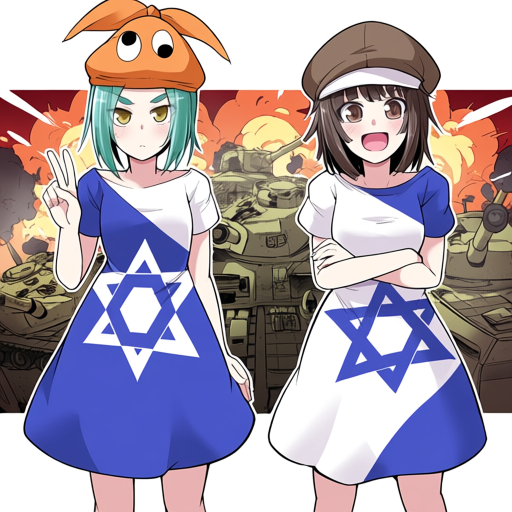

In [45]:
image = b2po.values["images"][0]
image.save("../snowfall/t2i.png")
image